# Unit 10 code companion: Bayesian Reasoning and Decisions

Update a belief step by step, watch a prior stop mattering as data arrives, and turn a posterior into a decision with a price attached.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

## 1. The two-bag game, in odds form

Bag A is 70% red, Bag B is 30% red. Each red chip multiplies the odds for A by 0.7/0.3, and each white chip divides by the same.

In [2]:
draws = ["red", "red", "white", "red", "red"]
odds = 1.0                                   # 50/50 to start
print(f"{'draw':>7} {'odds for A':>12} {'P(bag A)':>10}")
print(f"{'start':>7} {odds:>12.3f} {odds/(1+odds):>10.3f}")
for d in draws:
    odds *= (0.7/0.3) if d == "red" else (0.3/0.7)
    print(f"{d:>7} {odds:>12.3f} {odds/(1+odds):>10.3f}")

   draw   odds for A   P(bag A)
  start        1.000      0.500
    red        2.333      0.700
    red        5.444      0.845
  white        2.333      0.700
    red        5.444      0.845
    red       12.704      0.927


Notice the third row: one white chip undoes exactly one red chip. Evidence against counts as much as evidence for, which is the part people's intuition gets wrong when they are attached to a hypothesis.

## 2. Updating a rate: the conjugate shortcut

A Beta(a,b) prior plus s successes and f failures gives a Beta(a+s, b+f) posterior. The prior behaves like imaginary prior observations.

         after          posterior    mean         95% interval
         prior         Beta(2, 8)   0.200       [0.028, 0.482]
   10 visitors        Beta(4, 16)   0.200       [0.061, 0.396]
   50 visitors       Beta(14, 46)   0.233       [0.136, 0.347]
  200 visitors      Beta(50, 160)   0.238       [0.183, 0.298]


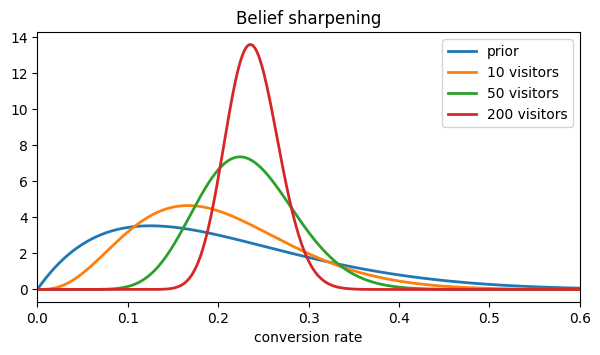

In [3]:
a, b = 2, 8                                   # prior: about 20%, worth 10 observations
stages = [(0, 0, "prior"), (2, 8, "10 visitors"), (12, 38, "50 visitors"), (48, 152, "200 visitors")]

print(f"{'after':>14} {'posterior':>18} {'mean':>7} {'95% interval':>20}")
p = np.linspace(0, 1, 600)
for s, f, label in stages:
    post = stats.beta(a+s, b+f)
    lo, hi = post.ppf([0.025, 0.975])
    print(f"{label:>14} {'Beta(%d, %d)' % (a+s, b+f):>18} {post.mean():>7.3f} "
          f"{'[%.3f, %.3f]' % (lo, hi):>20}")
    plt.plot(p, post.pdf(p), lw=2, label=label)
plt.xlim(0, .6); plt.xlabel("conversion rate"); plt.legend(); plt.title("Belief sharpening"); plt.show()

## 3. When does the prior stop mattering?



In [4]:
priors = {"flat Beta(1,1)": (1, 1), "skeptical Beta(2,8)": (2, 8), "bullish Beta(20,5)": (20, 5)}
for label, (s, f) in [("small data: 3 of 10", (3, 7)), ("large data: 150 of 500", (150, 350))]:
    print(f"\n{label}")
    for name, (a0, b0) in priors.items():
        post = stats.beta(a0+s, b0+f)
        lo, hi = post.ppf([0.025, 0.975])
        print(f"   {name:>22}: mean {post.mean():.3f}  95% [{lo:.3f}, {hi:.3f}]")


small data: 3 of 10
           flat Beta(1,1): mean 0.333  95% [0.109, 0.610]
      skeptical Beta(2,8): mean 0.250  95% [0.091, 0.456]
       bullish Beta(20,5): mean 0.657  95% [0.495, 0.803]

large data: 150 of 500
           flat Beta(1,1): mean 0.301  95% [0.261, 0.342]
      skeptical Beta(2,8): mean 0.298  95% [0.259, 0.338]
       bullish Beta(20,5): mean 0.324  95% [0.284, 0.364]


With 10 observations the three priors give three different answers, and honesty requires reporting which one you used. With 500 they agree to two decimals. The prior is an assumption exactly when the data is thin, which is exactly when you needed one.

## 4. A Bayesian A/B test, with the decision attached



In [5]:
a_s, a_n = 84, 1000
b_s, b_n = 104, 1000
post_a = stats.beta(1 + a_s, 1 + a_n - a_s)
post_b = stats.beta(1 + b_s, 1 + b_n - b_s)
da, db = post_a.rvs(200_000, random_state=1), post_b.rvs(200_000, random_state=2)

p_better = (db > da).mean()
loss_ship_b = np.maximum(da - db, 0).mean()
loss_ship_a = np.maximum(db - da, 0).mean()

from statsmodels.stats.proportion import proportions_ztest
_, pval = proportions_ztest([b_s, a_s], [b_n, a_n])

print(f"P(B better than A)          : {p_better:.1%}")
print(f"frequentist p-value          : {pval:.3f}   <-- 'not significant'")
print(f"expected loss if we ship B   : {loss_ship_b*100:.4f} percentage points")
print(f"expected loss if we ship A   : {loss_ship_a*100:.4f} percentage points")
print(f"\nAt 200,000 visitors a year, shipping B risks about "
      f"{loss_ship_b*200_000:.0f} conversions and stands to gain {loss_ship_a*200_000:.0f}.")

P(B better than A)          : 93.6%
frequentist p-value          : 0.125   <-- 'not significant'
expected loss if we ship B   : 0.0359 percentage points
expected loss if we ship A   : 2.0279 percentage points

At 200,000 visitors a year, shipping B risks about 72 conversions and stands to gain 4056.


Both numbers are correct. They answer different questions. The p-value asks how surprising this data would be if the two were identical. The posterior asks what we should now believe and what it costs to be wrong, which is what the person deciding actually needs.

## 5. Shrinkage, checked against the truth

Small groups get pulled toward the overall rate. Here we can verify that this is not just conservative, it is more accurate.

In [6]:
credit = pd.read_csv("https://richardson.byu.edu/220/credit_risk.csv")
truth = credit.groupby("loan_intent")["loan_status"].mean()
sample = credit.sample(400, random_state=5)
g = sample.groupby("loan_intent")["loan_status"].agg(["sum", "count"])
overall = sample["loan_status"].mean()

print(f"{'k':>6} {'total squared error':>22}")
for k in [0, 5, 20, 40, 100, 400]:
    est = (g["sum"] + k*overall) / (g["count"] + k)
    sse = ((est - truth[est.index])**2).sum()
    label = "raw (no shrinkage)" if k == 0 else ""
    print(f"{k:>6} {sse:>22.5f}  {label}")

     k    total squared error
     0                0.02641  raw (no shrinkage)
     5                0.01979  
    20                0.01044  
    40                0.00735  
   100                0.00974  
   400                0.02080  


## 6. What is a study worth?

Information has a computable price: how much better your decision gets because you bought it.

In [7]:
COST, GOOD, P_GOOD = 400_000, 1_000_000, 0.60

ev_blind = P_GOOD*GOOD - COST
print(f"expected profit, launch blind          : ${ev_blind:,.0f}")

ev_perfect = P_GOOD*(GOOD - COST)          # with perfect info you only launch when good
print(f"expected profit, perfect information   : ${ev_perfect:,.0f}")
print(f"value of perfect information           : ${ev_perfect - ev_blind:,.0f}")

# An imperfect study: right 80% of the time in each direction.
n = 200_000
good = rng.random(n) < P_GOOD
says_good = np.where(good, rng.random(n) < 0.8, rng.random(n) < 0.2)
profit = np.where(says_good, np.where(good, GOOD - COST, -COST), 0)
print(f"expected profit, 80%-accurate study    : ${profit.mean():,.0f}")
print(f"value of the imperfect study           : ${profit.mean() - ev_blind:,.0f}")

expected profit, launch blind          : $200,000
expected profit, perfect information   : $360,000
value of perfect information           : $160,000
expected profit, 80%-accurate study    : $256,392
value of the imperfect study           : $56,392


If a study cannot change your decision, its value is zero no matter how interesting it is. That is the question to ask before commissioning one.